<h1>Approaches to Machine Learning Task Three</h1>
<p>Continuing from previous tasks, design and train a model that takes in an image and classify it as a specific product then add it to the shopping list, eg. given an image of an apple, the model should classify the image as an apple, add it to the groceries list which is then classified into the "Fruits & Vegetables" category with Task 1's model.

Your model should be able to classify at least 4 types of grocery items in at least 2 different categories. Start with collecting relevant image data and preprocess them. You may use any techniques you wish to complete this task.</p>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras as keras
from keras import layers
from skimage.io import imread_collection
keras.backend.backend()

'tensorflow'

In [44]:
df = pd.read_csv("hf://datasets/AmirMohseni/GroceryList/data.csv")

# Source - https://stackoverflow.com/a
# Posted by Mariyan Zarev
# Retrieved 2026-01-27, License - CC BY-SA 3.0

#training images
milk_dir = 'images/train/milk/*.jpg'
garlic_dir = 'images/train/garlic/*.jpg'
bananas_dir = 'images/train/bananas/*.jpg'
carrot_dir = 'images/train/carrot/*.jpg'

#test image
milk_test = "images/test/milk/*.jpg"
garlic_test = "images/test/garlic/*.jpg"
bananas_test = "images/test/bananas/*.jpg"
carrot_test = "images/test/carrot/*.jpg"

#creating a collection with the available images
milk_train = imread_collection(milk_dir)
garlic_train = imread_collection(garlic_dir)
bananas_train = imread_collection(bananas_dir)
carrot_train = imread_collection(carrot_dir)

milk_test = imread_collection(milk_test)
garlic_test = imread_collection(garlic_test)
bananas_test = imread_collection(bananas_test)
carrot_test = imread_collection(carrot_test)


In [90]:
#loading the data
image_size = (348, 348)
batch_size = 128
labelled = ("Banana", "Carrots", "Garlic", "Milk")

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "images",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels = labelled,
    
)

ValueError: Expected the lengths of `labels` to match the number of files in the target directory. len(labels) is 4 while we found 143 files in directory images.

<Figure size 640x480 with 0 Axes>

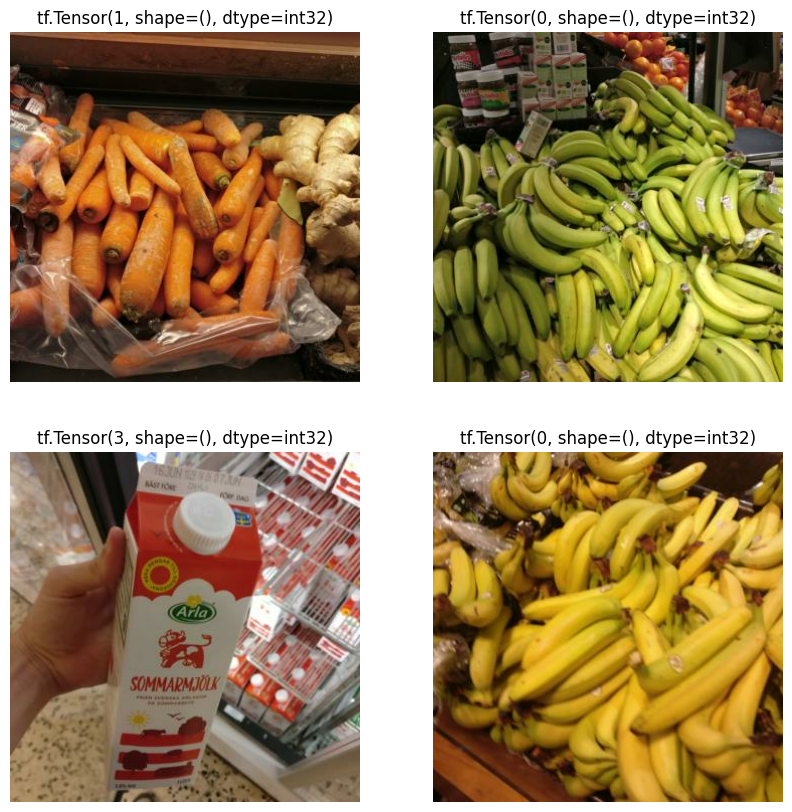

In [87]:
#0 is banana, 1 is carrot, 2 is garlic and 3 is milk
plt.clf()
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range (4):
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(labels[i])
        plt.axis("off")

plt.show()